# End to End Deep Learning Project Using Simple RNN

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import datetime

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, SimpleRNN, GRU, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.model_selection import train_test_split
from keras import initializers


In [2]:
# Load the Imdb dataset

max_features= 10000 ## vocabulary size
(X_train,y_train),(X_test,y_test)= imdb.load_data(num_words=max_features)

print(f'Training data shape: {X_train.shape}, training labels shape: {y_train.shape}')
print(f'Testing data shape: {X_test.shape}, testing labels shape: {y_test.shape}')

Training data shape: (25000,), training labels shape: (25000,)
Testing data shape: (25000,), testing labels shape: (25000,)


In [3]:
X_train[0]


[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [4]:
y_train[0]


np.int64(1)

In [5]:
## Inspect a sample review and its label

sample_review= X_train[0]
sample_label= y_train[0]


In [6]:
# Map word index to words
word_to_index= imdb.get_word_index()

word_to_index



{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [7]:
reverse_word_index= {value: key for key, value in word_to_index.items()}

reverse_word_index



{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [8]:
decoded_review= ' '.join([reverse_word_index.get(i -3, '?') for i in sample_review])

decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [9]:
max_length= 500

X_train= sequence.pad_sequences(X_train, maxlen=max_length)
X_test= sequence.pad_sequences(X_test, maxlen=max_length)

X_train[0]



array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

The IMDB dataset provided by Keras contains movie reviews that have already been preprocessed into Bag-of-Words format, where each word is represented by an integer index based on a predefined vocabulary size of 10,000. Along with the dataset, a dictionary mapping of words to their corresponding indices is provided, which makes it possible to decode the reviews back into their textual form.

Before the data can be used as input for a neural network, the sequence lengths must be standardized. This is accomplished using the pad_sequences method, where the maximum sequence length is set to 500. As a result, all reviews are either truncated or padded to ensure uniform shape, making them suitable for processing in the model pipeline.

# Train Simple RNN

## Test

In [10]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [11]:
initializer_1 = initializers.HeNormal(seed=42) # "glorot_Normal"
initializer_2 = initializers.GlorotNormal(seed=42)
initializer_3 = initializers.LecunNormal(seed=42)

In [12]:
model= Sequential()
model.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
model.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer="glorot_uniform"))
model.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer="glorot_uniform"))
model.add(Dense(1, activation='sigmoid'))


c:\Users\Rondon\Documents\1. Python Starter\16.krish_IA_Udemy\04.02.deep_learning_4_nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\Rondon\Documents\1. Python Starter\16.krish_IA_Udemy\04.02.deep_learning_4_nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
## Set Early Stopping

early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [15]:
## Set up the TensorBoard callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [16]:
Optimizer= Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=Optimizer, metrics=['accuracy'])



In [17]:

history= model.fit(X_train, y_train, epochs=500, batch_size=256, validation_split=0.2, callbacks=[early_stopping, tensorboard_callback], verbose=1)



Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 454ms/step - accuracy: 0.5301 - loss: 0.7040 - val_accuracy: 0.5080 - val_loss: 0.6999
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 488ms/step - accuracy: 0.5032 - loss: 0.7437 - val_accuracy: 0.5058 - val_loss: 0.7825
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 494ms/step - accuracy: 0.5164 - loss: 0.7103 - val_accuracy: 0.6378 - val_loss: 0.6584
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 507ms/step - accuracy: 0.7195 - loss: 0.5724 - val_accuracy: 0.7374 - val_loss: 0.5428
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 630ms/step - accuracy: 0.7911 - loss: 0.4559 - val_accuracy: 0.7758 - val_loss: 0.4820
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 644ms/step - accuracy: 0.8472 - loss: 0.3637 - val_accuracy: 0.7736 - val_loss: 0.4763
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 634ms/step - accuracy: 0.8519 - loss: 0.3501 - val_accuracy: 0.8160 - val_loss: 0.4702
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 633ms/step - accuracy: 0.8875 - loss: 0.2840 - 

In [18]:
## Load tensorboard
%load_ext tensorboard
%tensorboard --logdir=logs\fit\20250421-161321

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Failed to canonicalize script path

In [19]:
model.evaluate(X_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8208 - loss: 0.4475


[0.4484946131706238, 0.8221200108528137]

In [20]:
#model.save('pickle/simple_rnn_best_model.h5')


# RNN

initializer_1 = initializers.HeNormal(seed=42) 

initializer_2 = initializers.GlorotNormal(seed=42)

initializer_3 = initializers.LecunNormal(seed=42)

## HE 

In [21]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [22]:
RNN_HE= Sequential()
RNN_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_HE.add(SimpleRNN(128, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
RNN_HE.add(SimpleRNN(128, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
RNN_HE.add(Dense(1, activation='sigmoid'))

RNN_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [24]:
Optimizer= Adam(learning_rate=0.001)

RNN_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [25]:

history_RNN_HE= RNN_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)


Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 38s 455ms/step - accuracy: 0.5468 - loss: 0.6827 - val_accuracy: 0.6696 - val_loss: 0.6030
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 428ms/step - accuracy: 0.6883 - loss: 0.5890 - val_accuracy: 0.6424 - val_loss: 0.6036
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 425ms/step - accuracy: 0.6522 - loss: 1.8206 - val_accuracy: 0.5978 - val_loss: 0.6510
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 33s 420ms/step - accuracy: 0.6939 - loss: 0.5856 - val_accuracy: 0.6228 - val_loss: 0.6458
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 34s 434ms/step - accuracy: 0.6342 - loss: 40687988.0000 - val_accuracy: 0.5764 - val_loss: 0.6644
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 36s 461ms/step - accuracy: 0.6931 - loss: 0.6123 - val_accuracy: 0.5904 - val_loss: 0.6578
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 468ms/step - accuracy: 0.7132 - loss: 0.5933 - val_accuracy: 0.5890 - val_loss: 0.6570
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 37s 474ms/step - accuracy: 0.7242 - loss: 0.

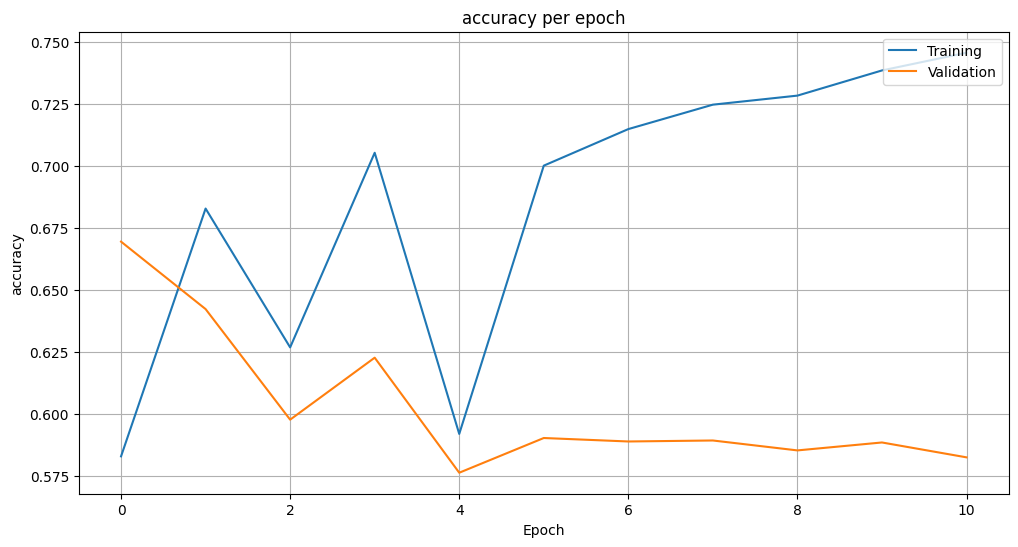

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_HE.history['accuracy'])
plt.plot(history_RNN_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [27]:
RNN_HE.evaluate(X_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.6773 - loss: 0.6041


[0.6008638739585876, 0.6781600117683411]

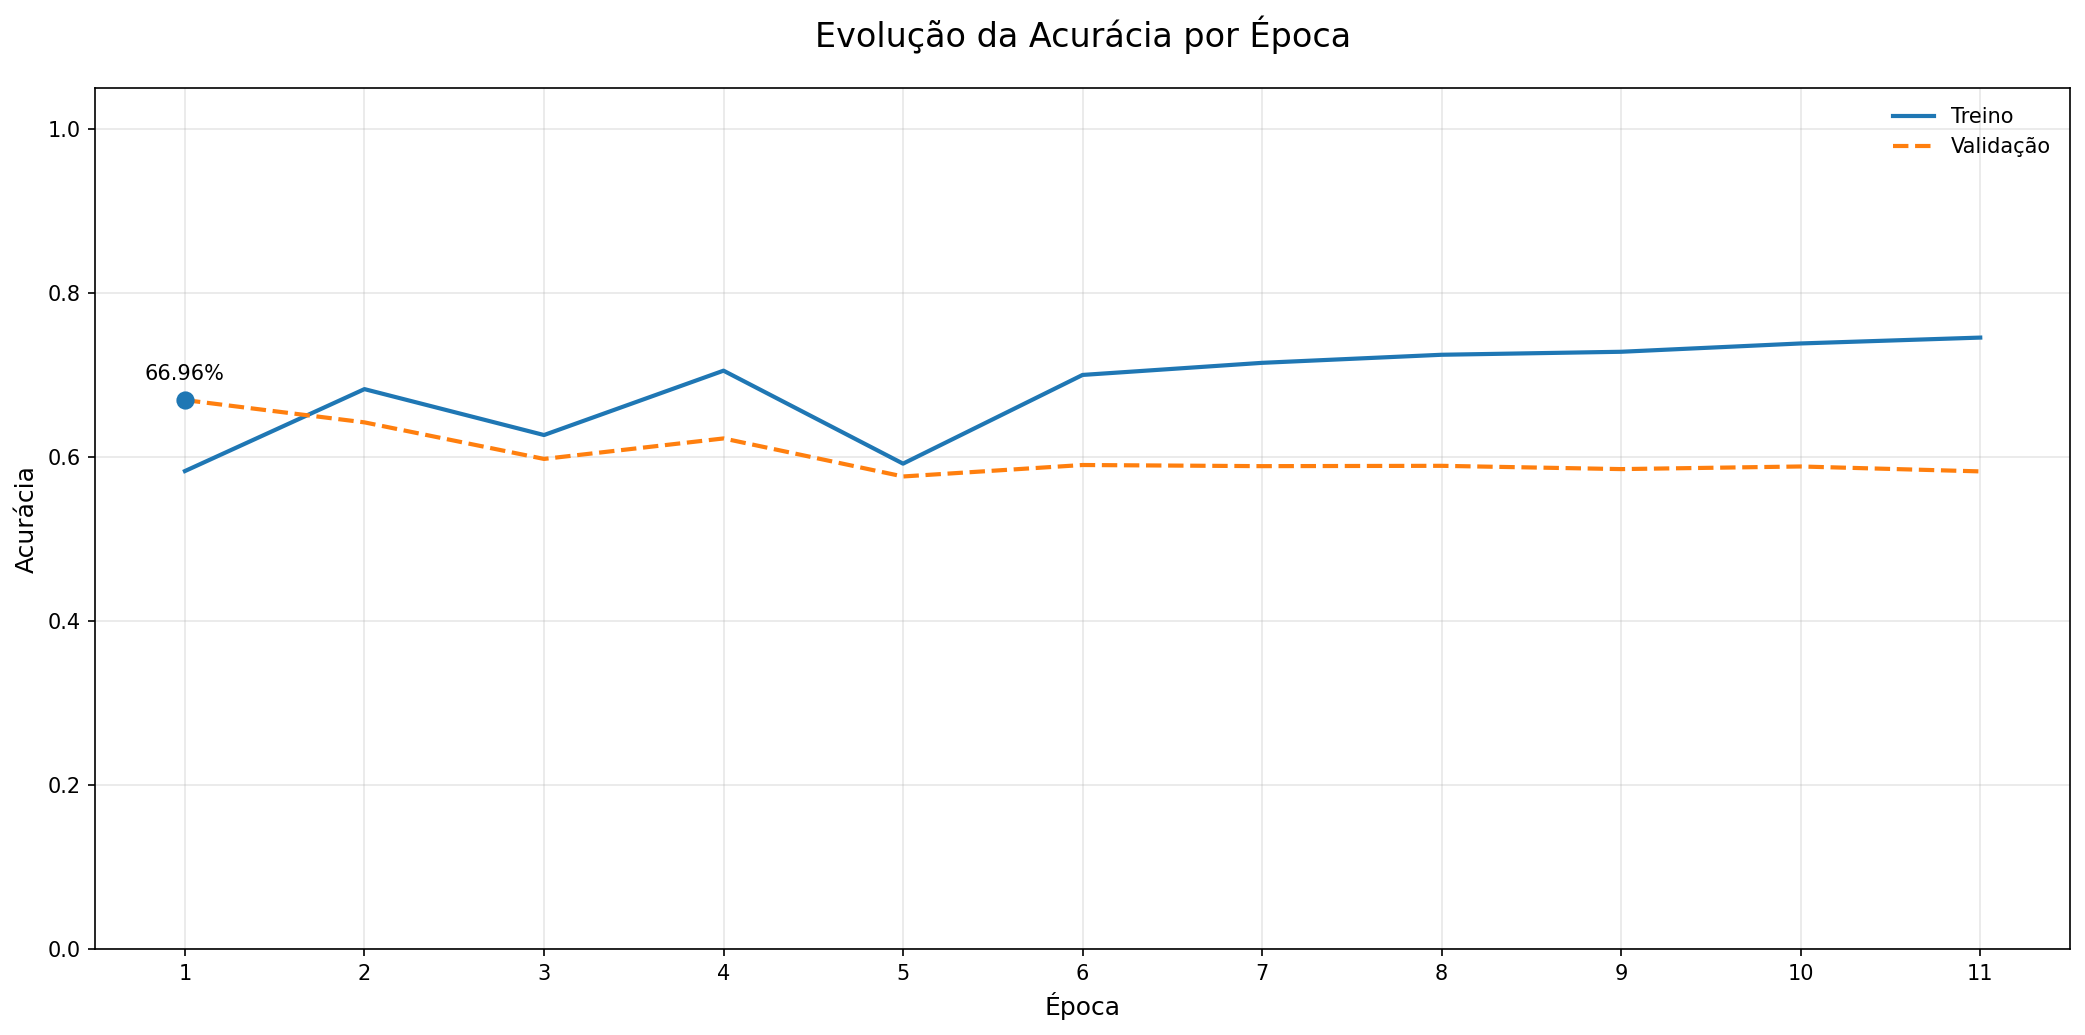

In [28]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_HE.history['accuracy']
val_acc   = history_RNN_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()

## GLorot

In [29]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [30]:
RNN_GL= Sequential()
RNN_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_GL.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
RNN_GL.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
RNN_GL.add(Dense(1, activation='sigmoid'))

RNN_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [32]:
Optimizer= Adam(learning_rate=0.001)

RNN_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [33]:
history_RNN_GL= RNN_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 41s 495ms/step - accuracy: 0.5152 - loss: 0.7096 - val_accuracy: 0.5710 - val_loss: 0.6680
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 495ms/step - accuracy: 0.6943 - loss: 0.5936 - val_accuracy: 0.7122 - val_loss: 0.5558
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 502ms/step - accuracy: 0.7593 - loss: 0.5001 - val_accuracy: 0.6922 - val_loss: 0.5734
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 502ms/step - accuracy: 0.8081 - loss: 0.4332 - val_accuracy: 0.7550 - val_loss: 0.4984
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 502ms/step - accuracy: 0.8414 - loss: 0.3643 - val_accuracy: 0.7776 - val_loss: 0.4851
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 497ms/step - accuracy: 0.7929 - loss: 0.4442 - val_accuracy: 0.8126 - val_loss: 0.4356
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 499ms/step - accuracy: 0.8520 - loss: 0.3537 - val_accuracy: 0.6208 - val_loss: 0.6518
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 499ms/step - accuracy: 0.6978 - loss: 0.5852 - 

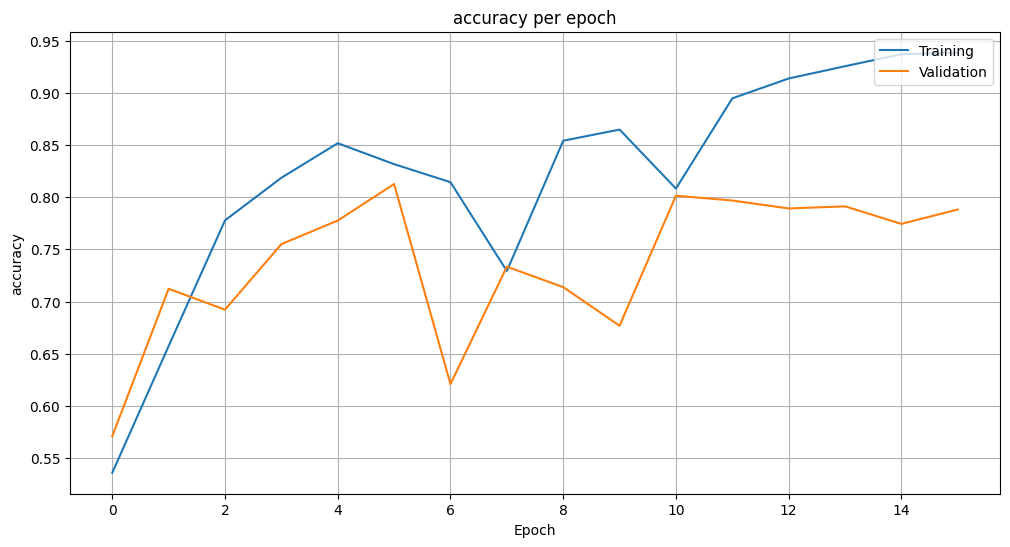

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_GL.history['accuracy'])
plt.plot(history_RNN_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [35]:
RNN_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8105 - loss: 0.4417


[0.43358081579208374, 0.811959981918335]

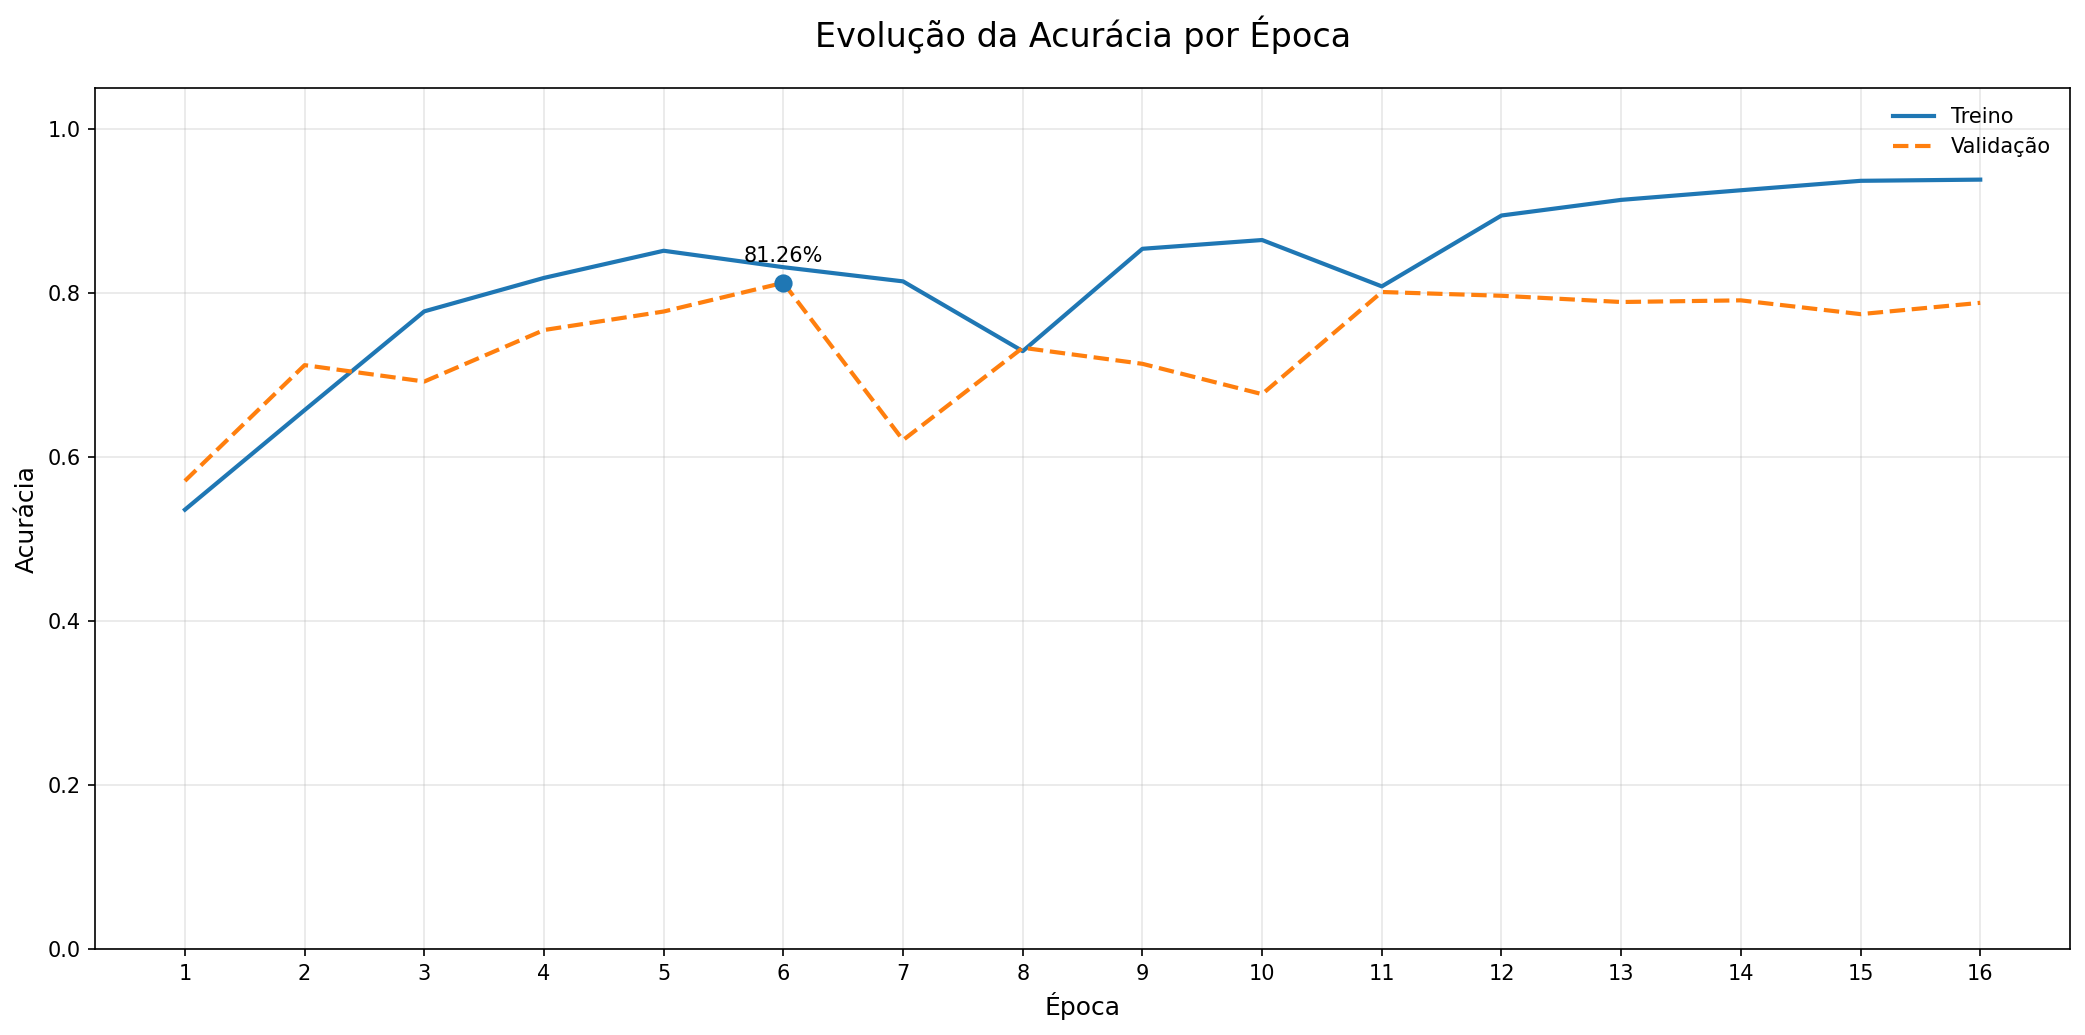

In [36]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_GL.history['accuracy']
val_acc   = history_RNN_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## LeCun

In [37]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [38]:
RNN_LE= Sequential()
RNN_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
RNN_LE.add(SimpleRNN(128, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
RNN_LE.add(SimpleRNN(128, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
RNN_LE.add(Dense(1, activation='sigmoid'))

RNN_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 500, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345,921 (5.13 MB)

 Trainable params: 1,345,921 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

RNN_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [40]:
history_RNN_LE= RNN_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 43s 512ms/step - accuracy: 0.5145 - loss: 0.6991 - val_accuracy: 0.5712 - val_loss: 0.6671
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 491ms/step - accuracy: 0.6581 - loss: 0.6286 - val_accuracy: 0.7098 - val_loss: 0.5559
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 488ms/step - accuracy: 0.7541 - loss: 0.5013 - val_accuracy: 0.7164 - val_loss: 0.5613
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 494ms/step - accuracy: 0.6507 - loss: 0.6267 - val_accuracy: 0.7166 - val_loss: 0.7262
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 493ms/step - accuracy: 0.7755 - loss: 0.4968 - val_accuracy: 0.8032 - val_loss: 0.4417
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 492ms/step - accuracy: 0.8317 - loss: 0.3924 - val_accuracy: 0.8148 - val_loss: 0.4449
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 489ms/step - accuracy: 0.8578 - loss: 0.3420 - val_accuracy: 0.8178 - val_loss: 0.5400
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 490ms/step - accuracy: 0.8516 - loss: 0.3815 - 

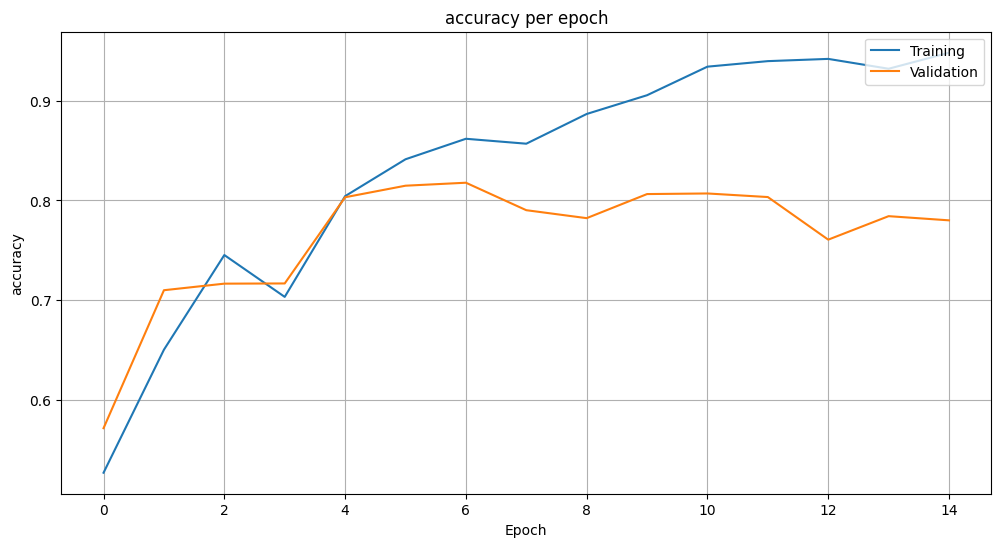

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(history_RNN_LE.history['accuracy'])
plt.plot(history_RNN_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [42]:
RNN_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8041 - loss: 0.4402


[0.43528372049331665, 0.8061599731445312]

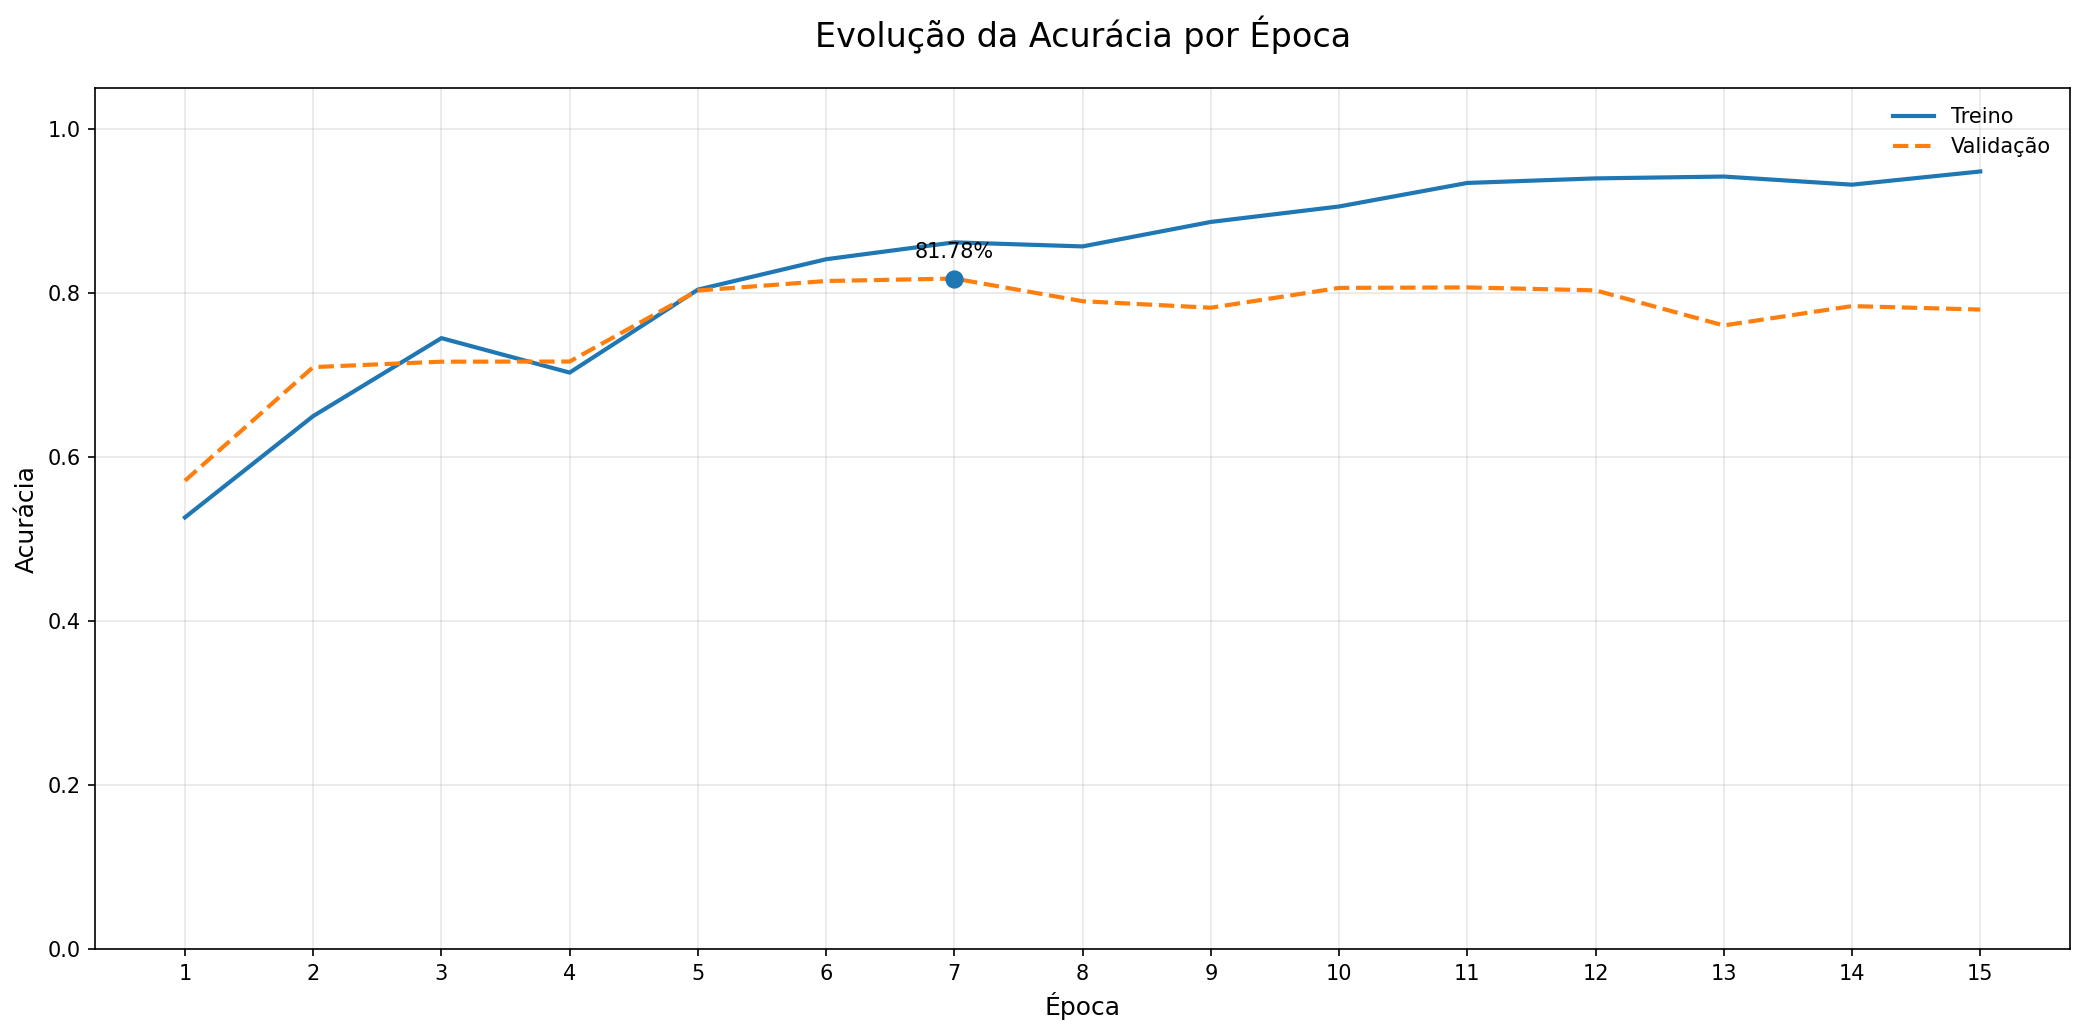

In [43]:


# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_RNN_LE.history['accuracy']
val_acc   = history_RNN_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


# LSTM

## HE 

In [44]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [45]:
LSTM_HE= Sequential()
LSTM_HE.add(Embedding(max_features, 50, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_HE.add(LSTM(64, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(Dropout(0.2))
LSTM_HE.add(LSTM(32, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(Dropout(0.2))
LSTM_HE.add(LSTM(32, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
LSTM_HE.add(Dense(1, activation='sigmoid', kernel_initializer=initializer_2))

LSTM_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 500, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,209 (2.10 MB)

 Trainable params: 550,209 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Optimizer= Adam(learning_rate=0.001)

LSTM_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [47]:
history_LSTM_HE= LSTM_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.5425 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.4999 - loss: nan - val_accuracy: 0.5062 - val_loss: nan
Epoch 9/500
79/79 ━━━━━━

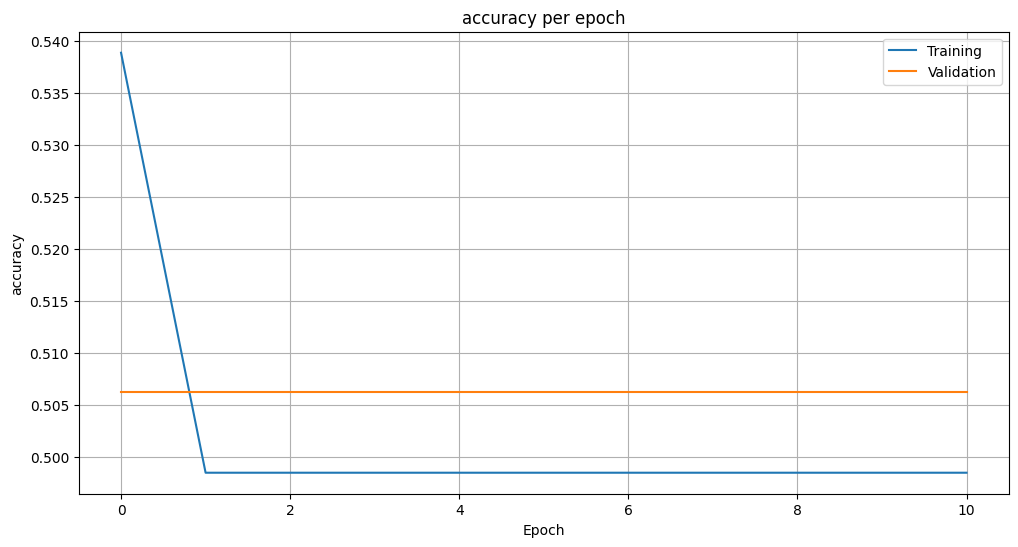

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_HE.history['accuracy'])
plt.plot(history_LSTM_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [49]:
LSTM_HE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 89s 114ms/step - accuracy: 0.5073 - loss: nan


[nan, 0.5]

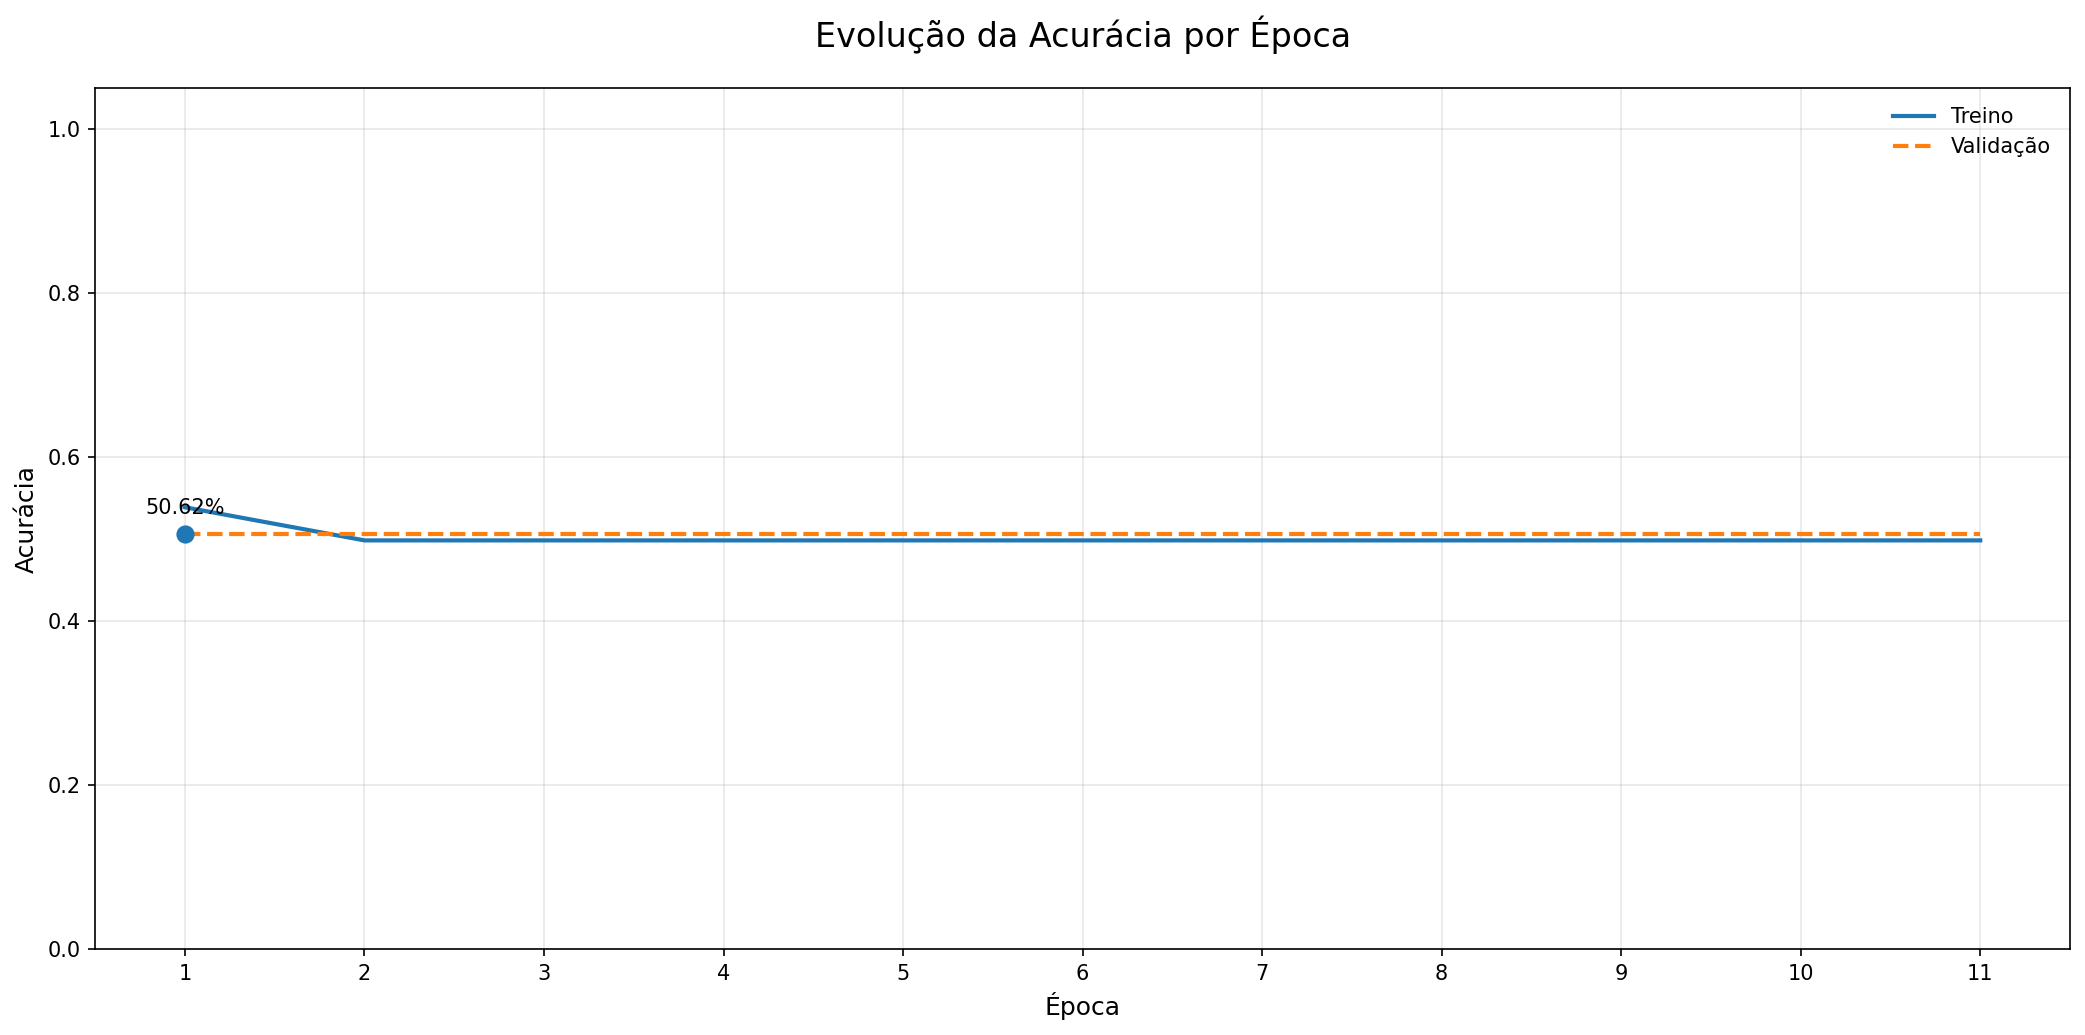

In [50]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_HE.history['accuracy']
val_acc   = history_LSTM_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## GLorot

In [51]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [52]:
LSTM_GL= Sequential()
LSTM_GL.add(Embedding(max_features, 50, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_GL.add(LSTM(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(Dropout(0.2))
LSTM_GL.add(LSTM(32, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(Dropout(0.2))
LSTM_GL.add(LSTM(32, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
LSTM_GL.add(Dense(1, activation='sigmoid', kernel_initializer=initializer_2))

LSTM_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 500, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,209 (2.10 MB)

 Trainable params: 550,209 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

LSTM_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [54]:
history_LSTM_GL= LSTM_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.5965 - loss: 0.6446 - val_accuracy: 0.8158 - val_loss: 0.4256
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8452 - loss: 0.3697 - val_accuracy: 0.8404 - val_loss: 0.3720
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8934 - loss: 0.2766 - val_accuracy: 0.8036 - val_loss: 0.4280
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9020 - loss: 0.2552 - val_accuracy: 0.8262 - val_loss: 0.4058
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.8997 - loss: 0.2559 - val_accuracy: 0.6754 - val_loss: 1.0129
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.8186 - loss: 0.4569 - val_accuracy: 0.8592 - val_loss: 0.4379
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.9272 - loss: 0.2085 - val_accuracy: 0.8046 - val_loss: 0.6079
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.8563 - loss: 0.3738 - val_accuracy: 0.

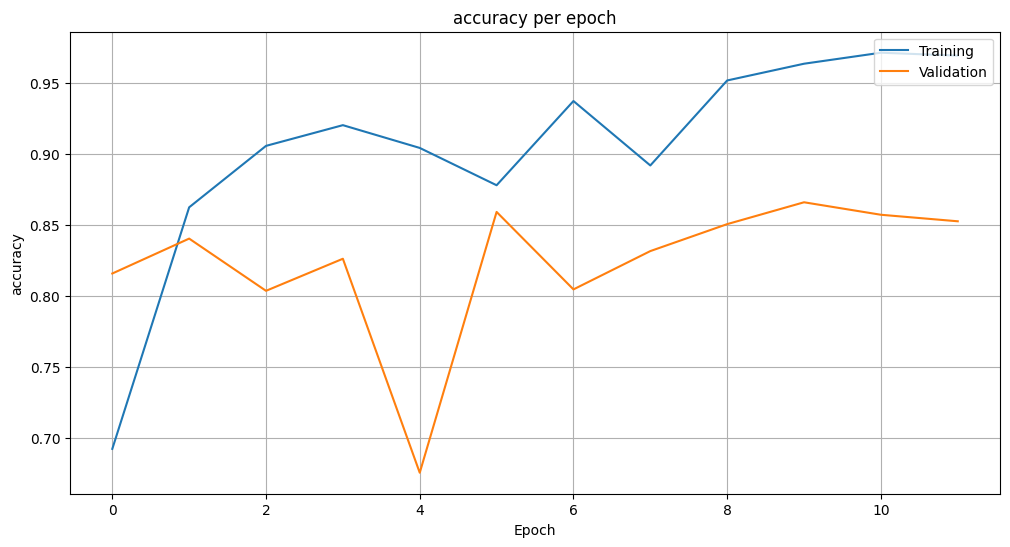

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_GL.history['accuracy'])
plt.plot(history_LSTM_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [56]:
LSTM_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 129ms/step - accuracy: 0.8340 - loss: 0.3766


[0.37535980343818665, 0.8337600231170654]

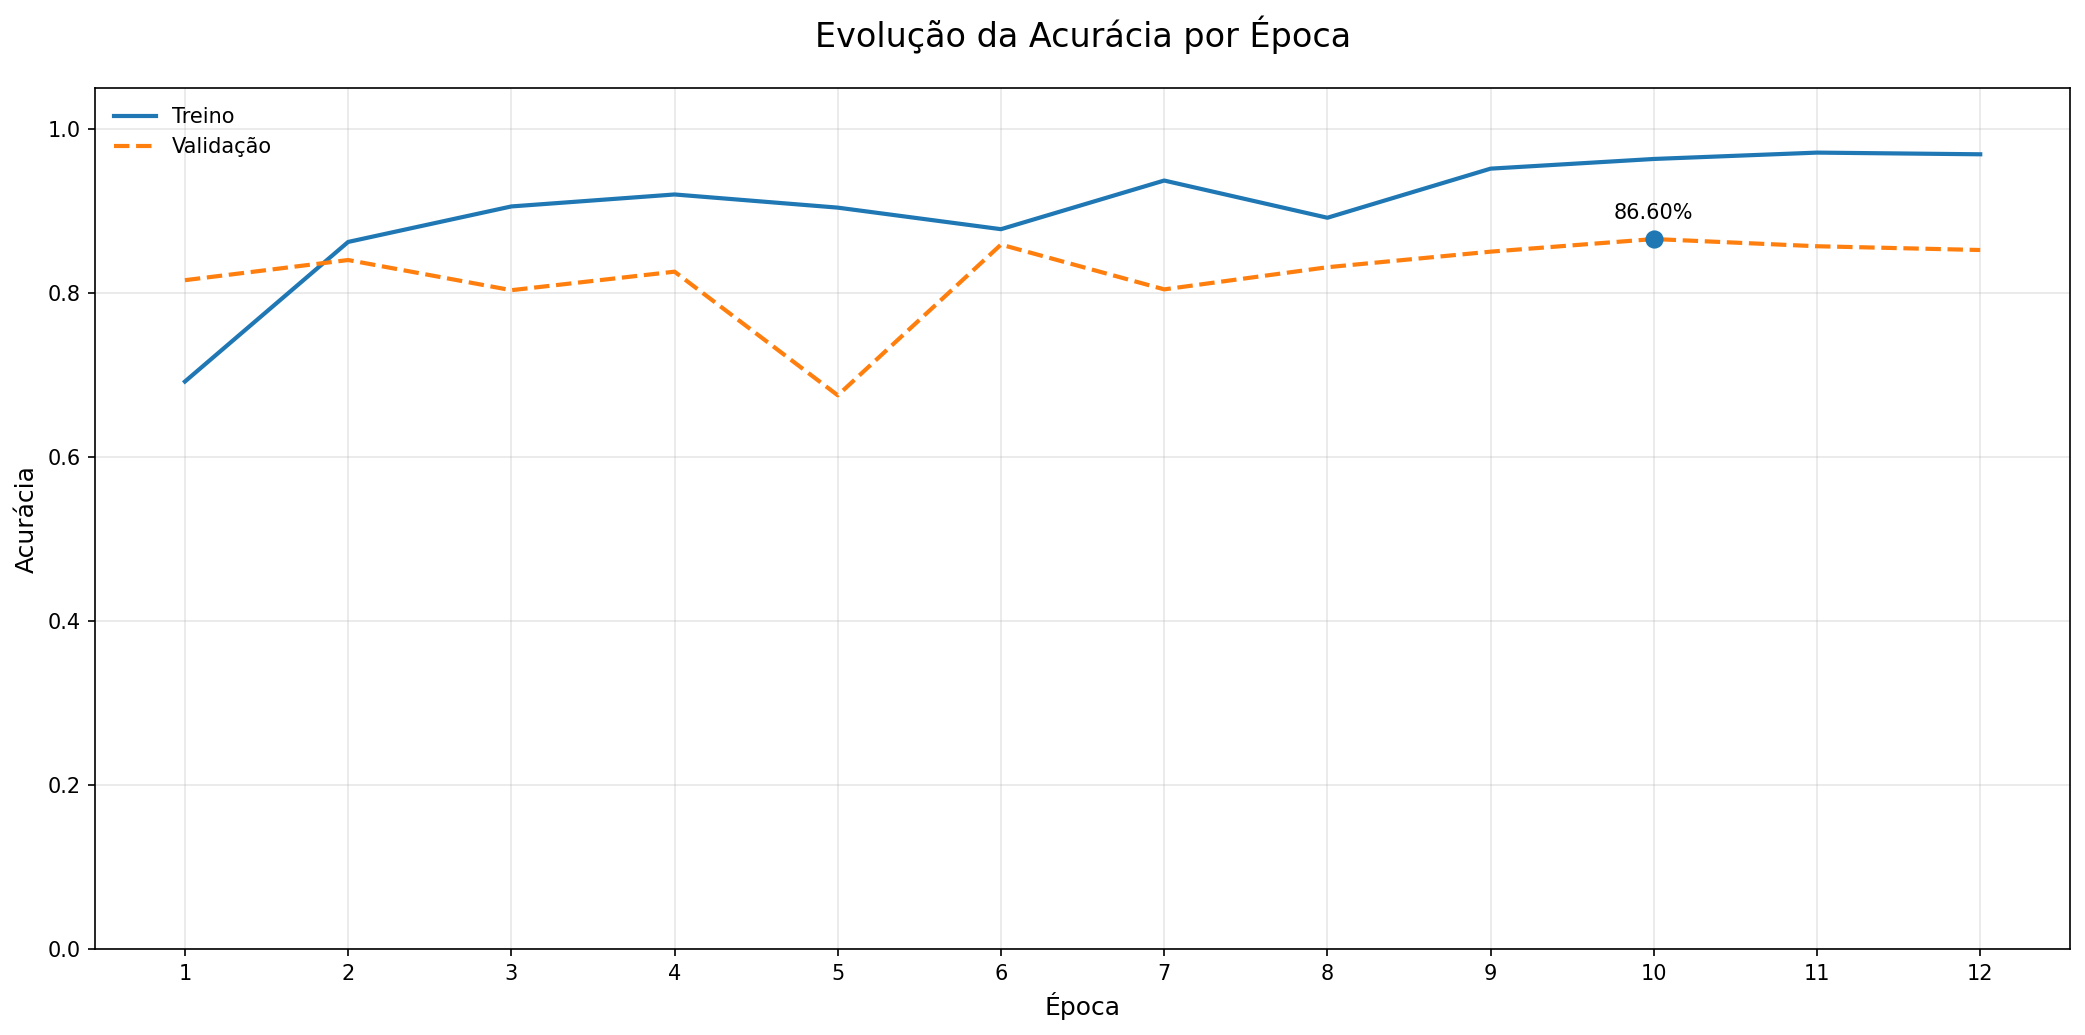

In [57]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_GL.history['accuracy']
val_acc   = history_LSTM_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()





## LeCun

In [58]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [59]:
LSTM_LE= Sequential()
LSTM_LE.add(Embedding(max_features, 50, input_length=max_length, input_shape=X_train.shape[1:]))
LSTM_LE.add(LSTM(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(Dropout(0.2))
LSTM_LE.add(LSTM(32, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(Dropout(0.2))
LSTM_LE.add(LSTM(32, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
LSTM_LE.add(Dense(1, activation='sigmoid', kernel_initializer=initializer_3))

LSTM_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 500, 64)        │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 500, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,209 (2.10 MB)

 Trainable params: 550,209 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

LSTM_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [61]:
history_LSTM_LE= LSTM_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.6105 - loss: 0.6305 - val_accuracy: 0.8328 - val_loss: 0.3951
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8598 - loss: 0.3434 - val_accuracy: 0.8750 - val_loss: 0.3087
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.9175 - loss: 0.2247 - val_accuracy: 0.8250 - val_loss: 0.4714
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9127 - loss: 0.2305 - val_accuracy: 0.8220 - val_loss: 0.4471
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9198 - loss: 0.2132 - val_accuracy: 0.8676 - val_loss: 0.3406
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9326 - loss: 0.1834 - val_accuracy: 0.8622 - val_loss: 0.4204
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9269 - loss: 0.1930 - val_accuracy: 0.8154 - val_loss: 0.5173
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.9377 - loss: 0.1688 - val_accuracy: 0.

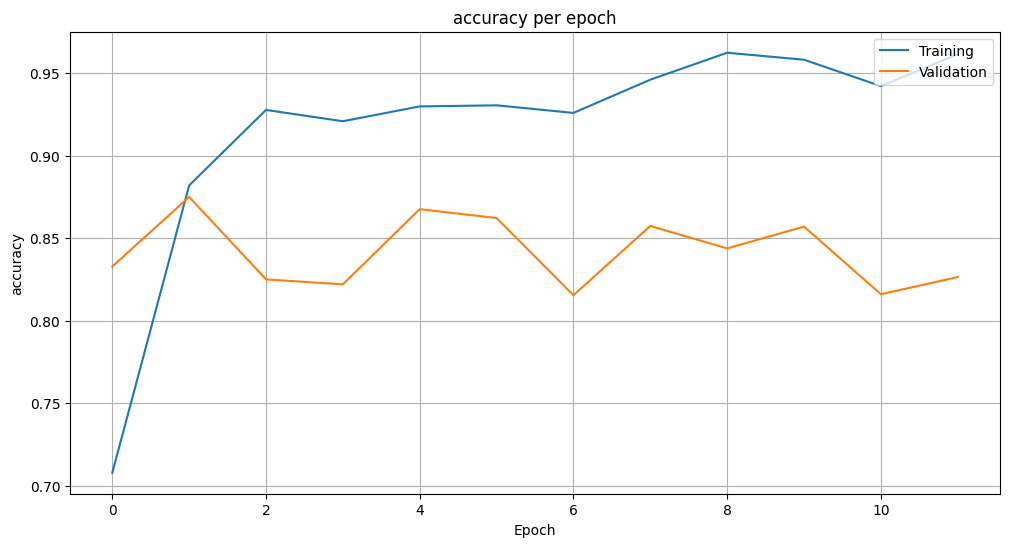

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(history_LSTM_LE.history['accuracy'])
plt.plot(history_LSTM_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [63]:
LSTM_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 181ms/step - accuracy: 0.8642 - loss: 0.3213


[0.3200284242630005, 0.8652399778366089]

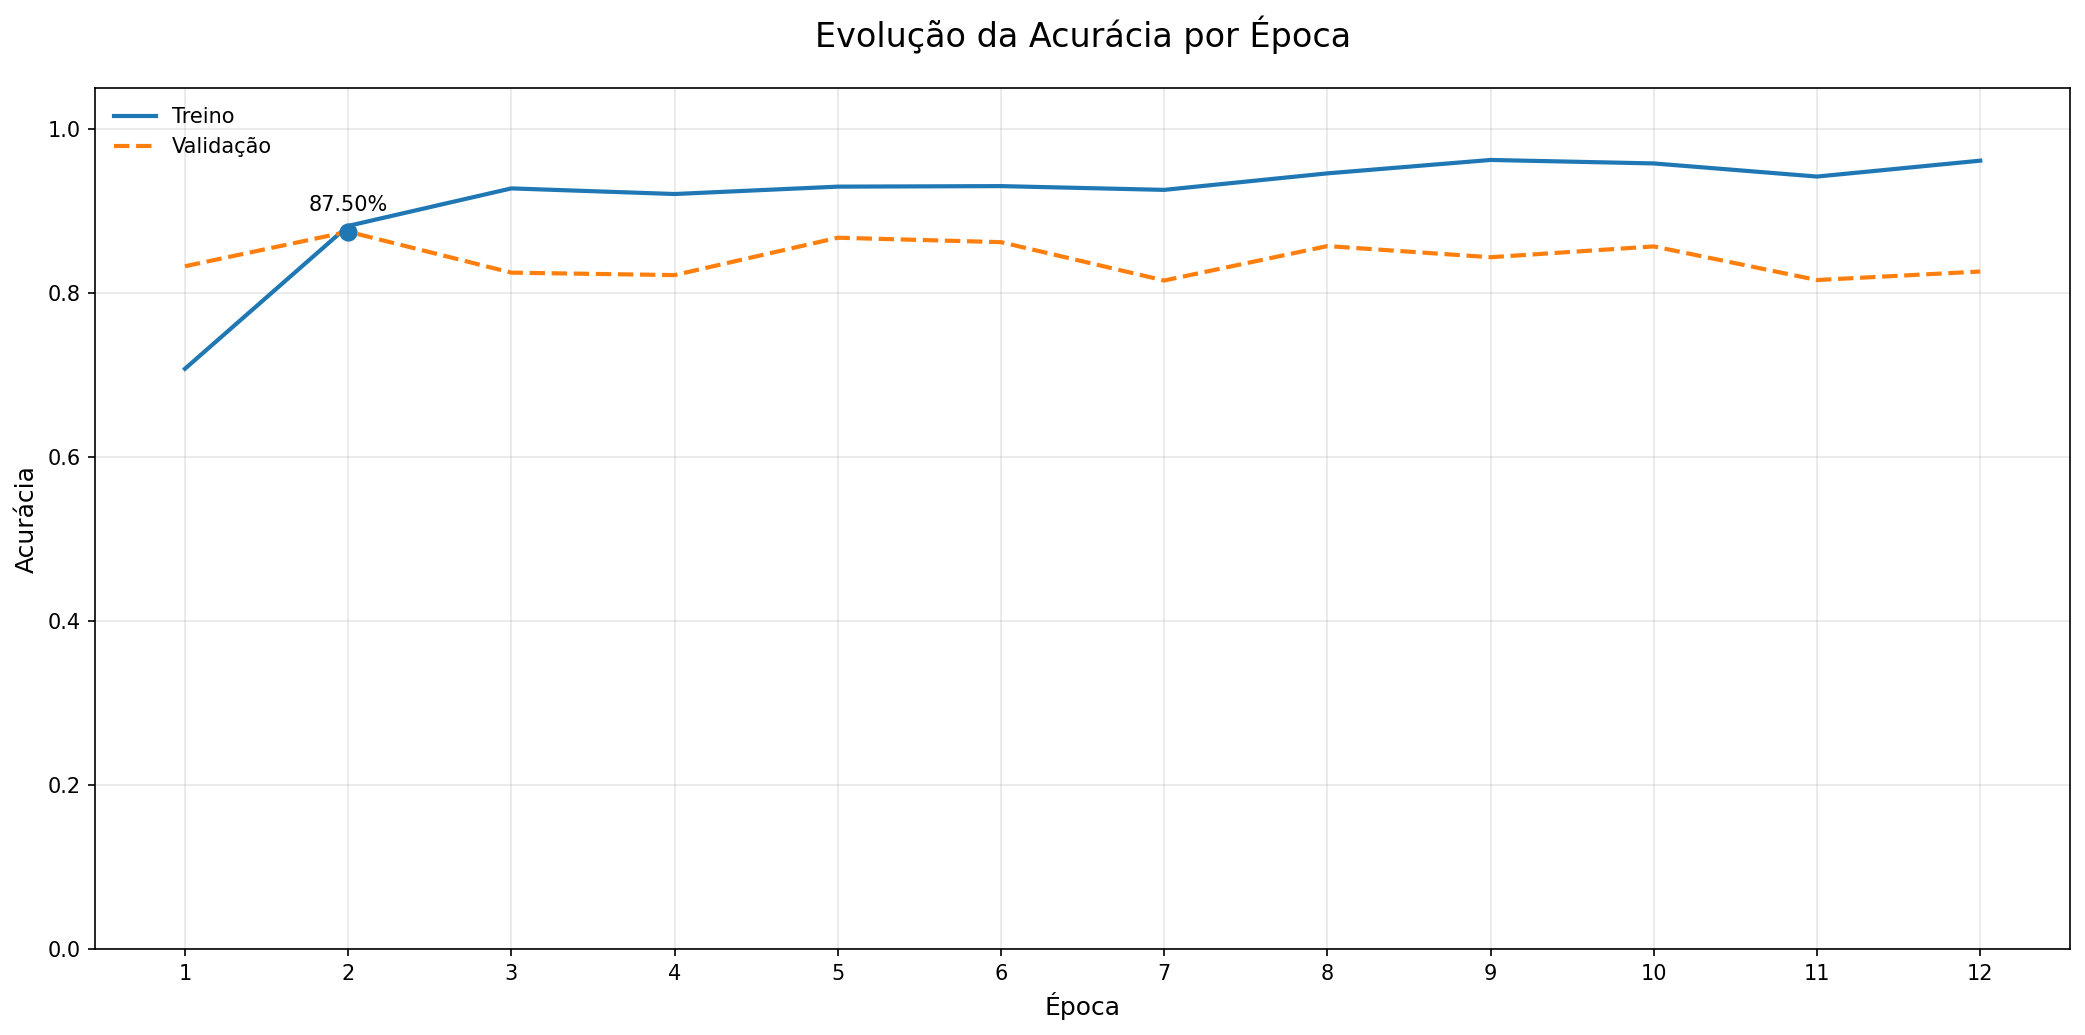

In [64]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_LSTM_LE.history['accuracy']
val_acc   = history_LSTM_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


# GRU

## HE

In [65]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [66]:
GRU_HE= Sequential()
GRU_HE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_HE.add(GRU(64, return_sequences=True,activation="relu", kernel_initializer=initializer_1))
GRU_HE.add(GRU(64, return_sequences=False,activation="relu", kernel_initializer=initializer_1))
GRU_HE.add(Dense(1, activation='sigmoid'))

GRU_HE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Optimizer= Adam(learning_rate=0.001)

GRU_HE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [68]:
history_GRU_HE= GRU_HE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - accuracy: 0.5937 - loss: 0.6591 - val_accuracy: 0.7506 - val_loss: 0.4864
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.7829 - loss: 0.5876 - val_accuracy: 0.8422 - val_loss: 0.3762
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.8831 - loss: 0.2757 - val_accuracy: 0.8088 - val_loss: 0.4541
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.9083 - loss: 0.2263 - val_accuracy: 0.8126 - val_loss: 0.4237
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.9237 - loss: 0.1923 - val_accuracy: 0.8726 - val_loss: 0.3504
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 0.9465 - loss: 0.1378 - val_accuracy: 0.8438 - val_loss: 0.4809
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.9482 - loss: 0.1318 - val_accuracy: 0.8706 - val_loss: 0.4034
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.9532 - loss: 0.1169 - val_accuracy: 0.

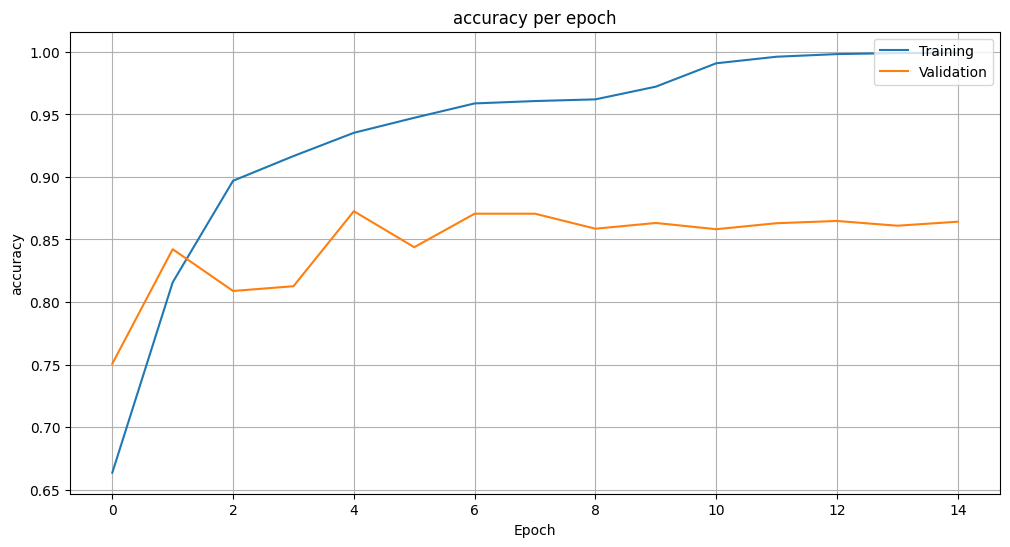

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_HE.history['accuracy'])
plt.plot(history_GRU_HE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [70]:
GRU_HE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.8678 - loss: 0.3677


[0.3613417148590088, 0.8694000244140625]

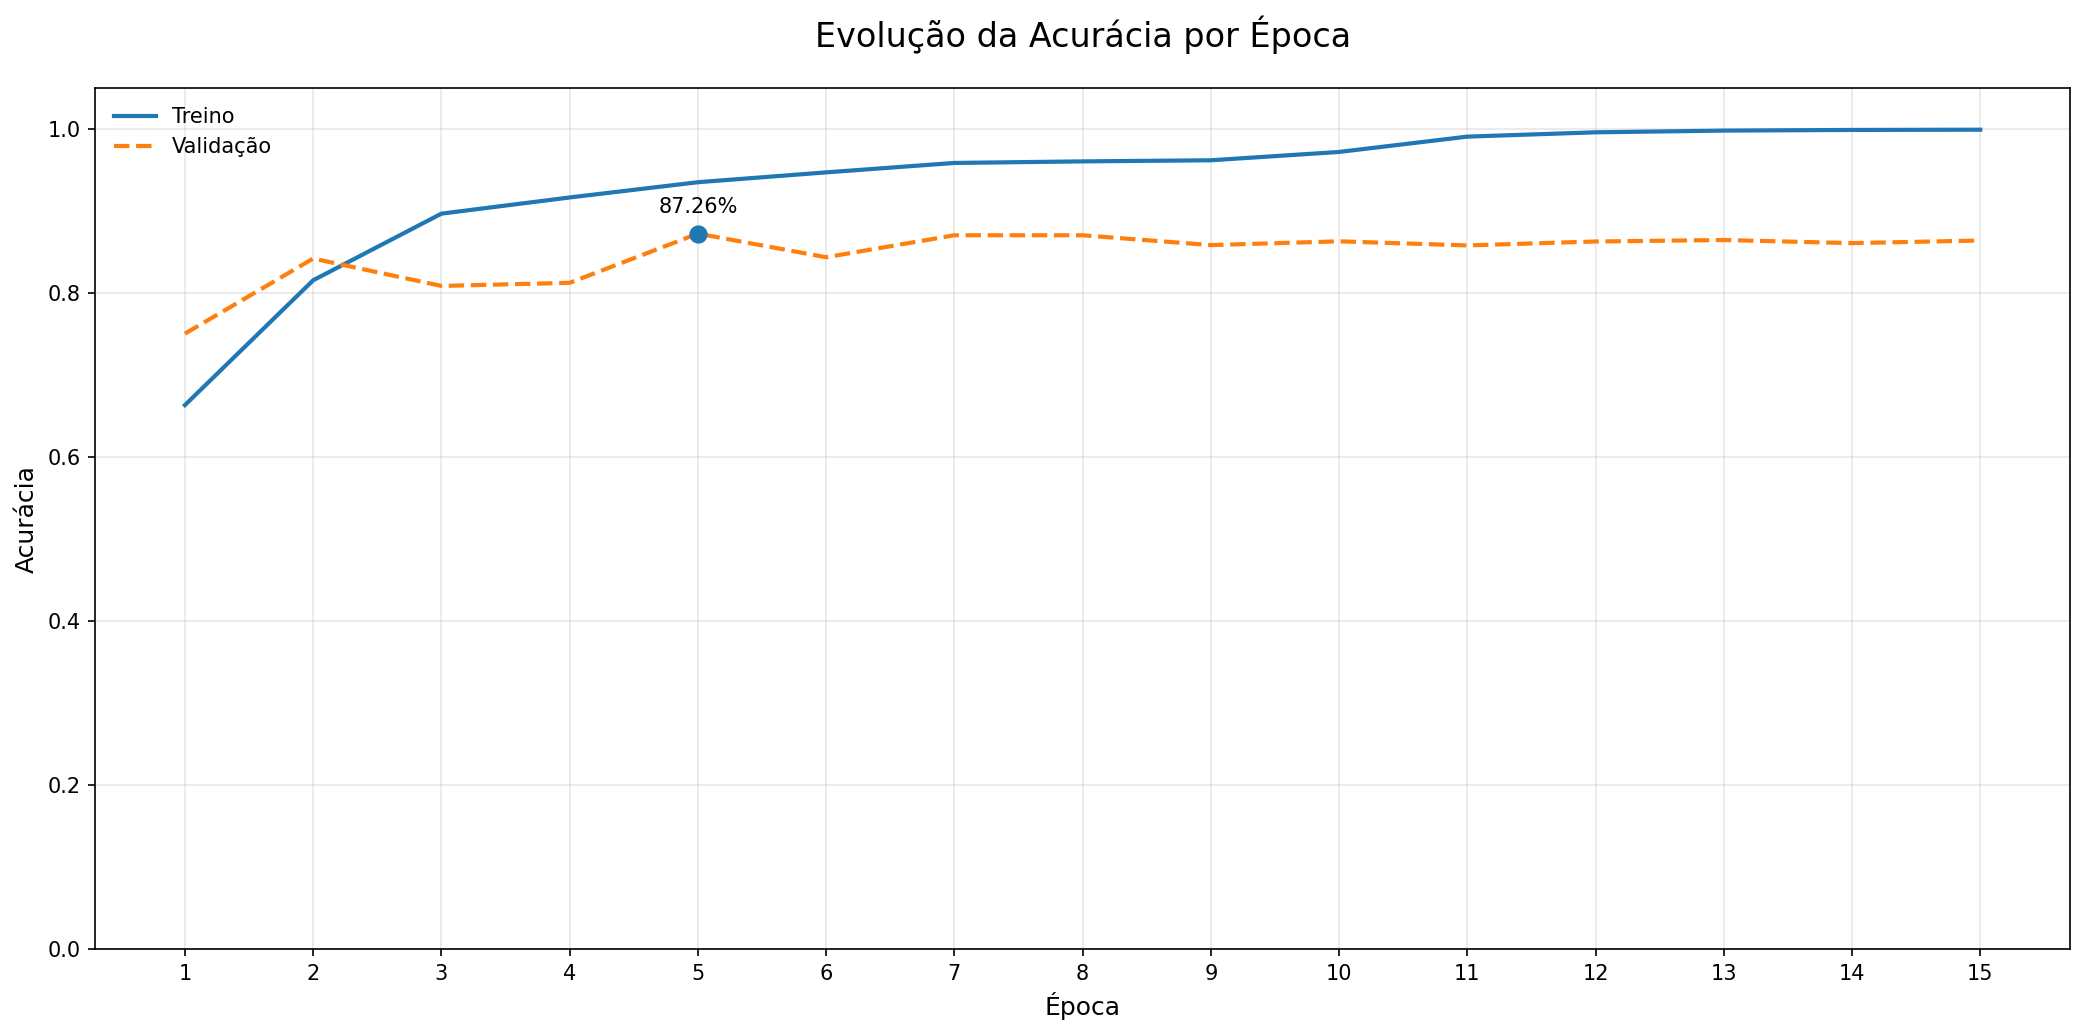

In [71]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_HE.history['accuracy']
val_acc   = history_GRU_HE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## GLorot

In [72]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [73]:
GRU_GL= Sequential()
GRU_GL.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_GL.add(GRU(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_2))
GRU_GL.add(GRU(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_2))
GRU_GL.add(Dense(1, activation='sigmoid'))

GRU_GL.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

GRU_GL.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [75]:
history_GRU_GL= GRU_GL.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - accuracy: 0.6124 - loss: 0.6258 - val_accuracy: 0.8270 - val_loss: 0.3834
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - accuracy: 0.8699 - loss: 0.3093 - val_accuracy: 0.8590 - val_loss: 0.3644
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.9015 - loss: 0.2425 - val_accuracy: 0.7722 - val_loss: 0.4688
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - accuracy: 0.8647 - loss: 0.3126 - val_accuracy: 0.8354 - val_loss: 0.3884
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - accuracy: 0.9321 - loss: 0.1833 - val_accuracy: 0.8616 - val_loss: 0.3685
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - accuracy: 0.9441 - loss: 0.1454 - val_accuracy: 0.8102 - val_loss: 0.5029
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.9425 - loss: 0.1551 - val_accuracy: 0.8062 - val_loss: 0.5488
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.9195 - loss: 0.1970 - val_accuracy: 0.

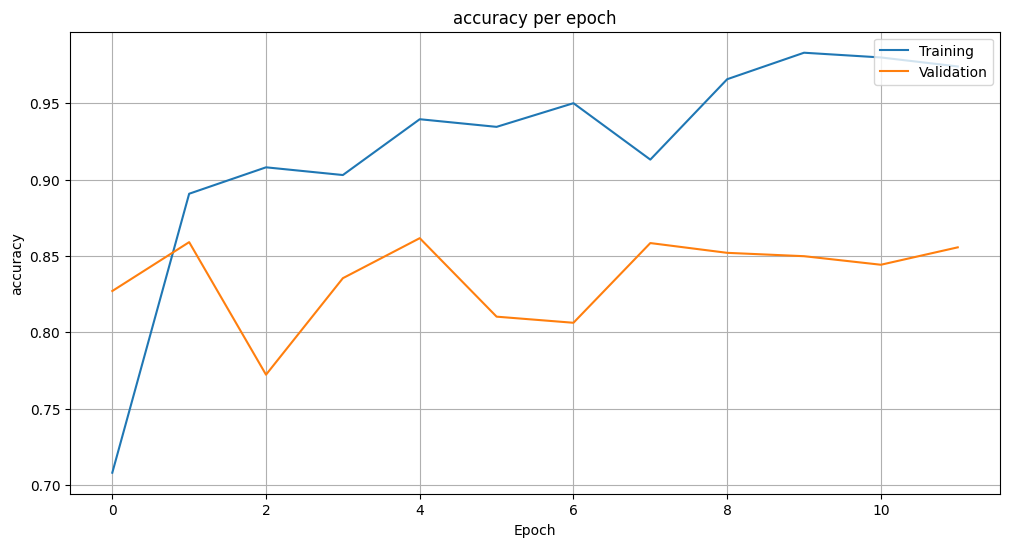

In [76]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_GL.history['accuracy'])
plt.plot(history_GRU_GL.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [77]:
GRU_GL.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 66ms/step - accuracy: 0.8498 - loss: 0.3770


[0.3708494007587433, 0.8511199951171875]

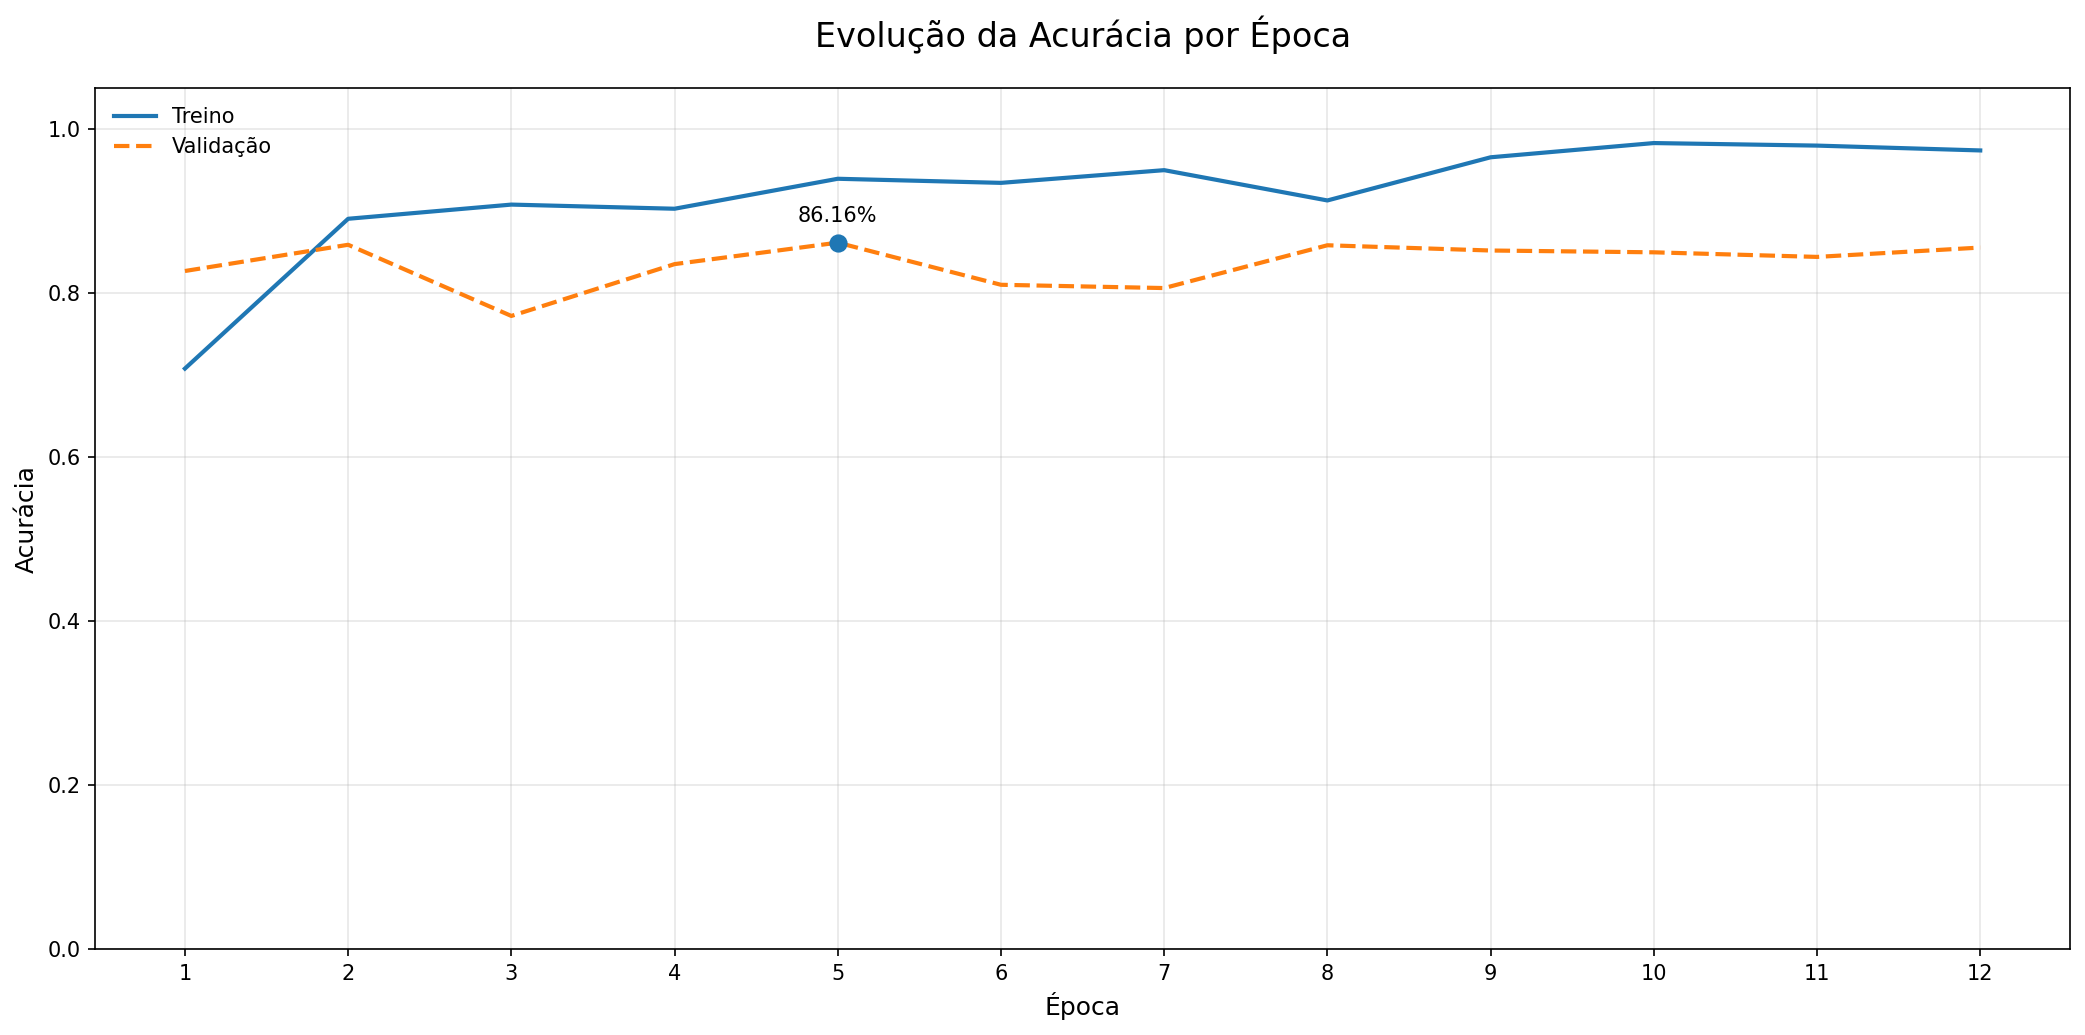

In [78]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_GL.history['accuracy']
val_acc   = history_GRU_GL.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()


## LeCun

In [79]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

In [80]:
GRU_LE= Sequential()
GRU_LE.add(Embedding(max_features, 128, input_length=max_length, input_shape=X_train.shape[1:]))
GRU_LE.add(GRU(64, return_sequences=True,activation="tanh", kernel_initializer=initializer_3))
GRU_LE.add(GRU(64, return_sequences=False,activation="tanh", kernel_initializer=initializer_3))
GRU_LE.add(Dense(1, activation='sigmoid'))

GRU_LE.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 500, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,273 (5.12 MB)

 Trainable params: 1,342,273 (5.12 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
early_stopping= EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
Optimizer= Adam(learning_rate=0.001)

GRU_LE.compile(loss='binary_crossentropy', 
               optimizer=Optimizer, 
               metrics=['accuracy'])

In [82]:
history_GRU_LE= GRU_LE.fit(X_train, y_train, 
                           epochs=500, 
                           batch_size=256, 
                           validation_split=0.2, 
                           callbacks=[early_stopping], 
                           verbose=1)

Epoch 1/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.6232 - loss: 0.6144 - val_accuracy: 0.8482 - val_loss: 0.3485
Epoch 2/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 0.8739 - loss: 0.3061 - val_accuracy: 0.8672 - val_loss: 0.3214
Epoch 3/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.9182 - loss: 0.2131 - val_accuracy: 0.8326 - val_loss: 0.3730
Epoch 4/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.9139 - loss: 0.2132 - val_accuracy: 0.8592 - val_loss: 0.3699
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.9256 - loss: 0.1922 - val_accuracy: 0.8174 - val_loss: 0.6086
Epoch 6/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9215 - loss: 0.2030 - val_accuracy: 0.8654 - val_loss: 0.4472
Epoch 7/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.9602 - loss: 0.1103 - val_accuracy: 0.8526 - val_loss: 0.5213
Epoch 8/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.9689 - loss: 0.0901 - val_accuracy: 0.

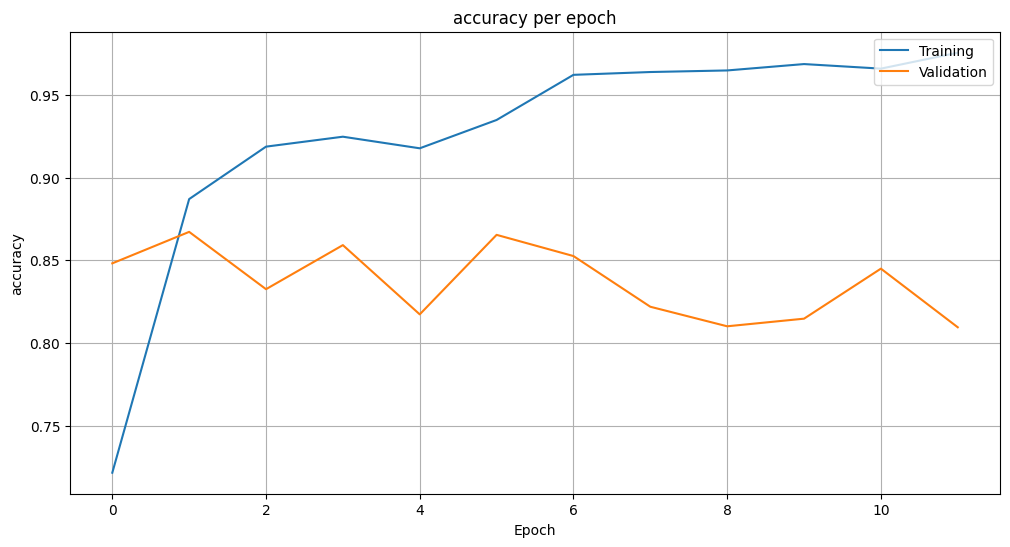

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(history_GRU_LE.history['accuracy'])
plt.plot(history_GRU_LE.history['val_accuracy'])
plt.title('accuracy per epoch')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.show()

In [84]:
GRU_LE.evaluate(X_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.8552 - loss: 0.3368


[0.3338244557380676, 0.8578799962997437]

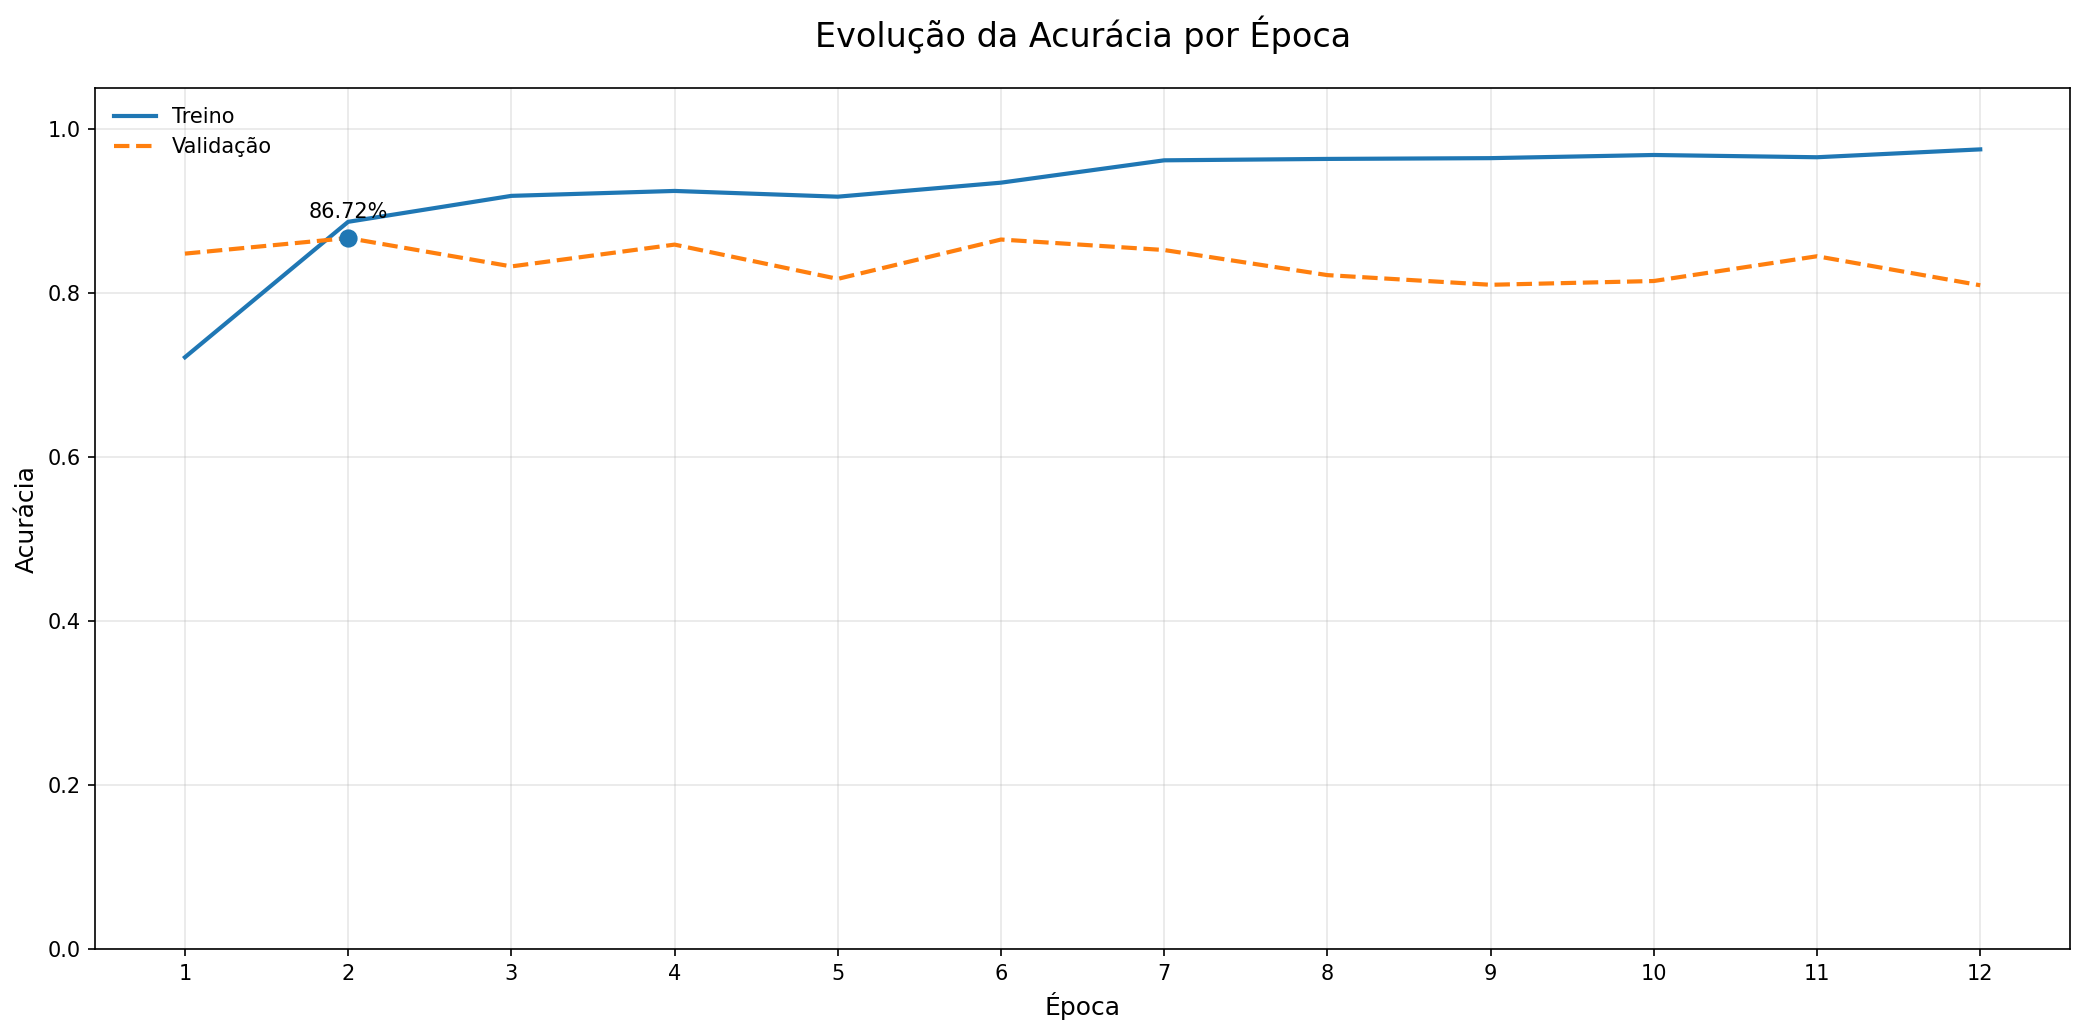

In [85]:
# ─── DADOS ──────────────────────────────────────────────────────────────────────
train_acc = history_GRU_LE.history['accuracy']
val_acc   = history_GRU_LE.history['val_accuracy']
epochs    = range(1, len(train_acc) + 1)

# ─── FIGURA ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7), dpi=150)

# Curva de treino
plt.plot(epochs, train_acc,
         label='Treino',
         linewidth=2)

# Curva de validação
plt.plot(epochs, val_acc,
         label='Validação',
         linewidth=2,
         linestyle='--')

# ─── REALCES ÚTEIS ──────────────────────────────────────────────────────────────
# Aponta a melhor época na validação
best_ep   = max(range(len(val_acc)), key=val_acc.__getitem__)
best_val  = val_acc[best_ep]
plt.scatter(best_ep + 1, best_val, s=60, zorder=5)
plt.text(best_ep + 1, best_val + 0.02,
         f'{best_val:.2%}',
         ha='center', va='bottom', fontsize=10)

# ─── ESTILO GERAL ───────────────────────────────────────────────────────────────
plt.title('Evolução da Acurácia por Época', fontsize=16, pad=20)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Acurácia', fontsize=12)
plt.xticks(epochs)              # mostra todas as épocas no eixo-x
plt.ylim(0, 1.05)               # garante visibilidade até 100 %
plt.grid(alpha=0.3)             # grid suave
plt.legend(frameon=False)       # sem moldura no legend
plt.tight_layout()              # encaixa tudo

plt.show()
